# Load Packages

In [59]:
# ==============================
# Install required packages
# ==============================
!pip install -q --upgrade pip
!pip install -q pyunpack patool rarfile rioxarray rasterio xarray

# ==============================
# Standard library
# ==============================
import os
import sys
import glob
import pathlib
import zipfile

# ==============================
# General utilities
# ==============================
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==============================
# Image handling
# ==============================
import PIL
from PIL import Image

# ==============================
# Raster / geospatial
# ==============================
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.windows import Window
import rioxarray as rxr

# ==============================
# Archive handling
# ==============================
import pyunpack
from rarfile import RarFile

# ==============================
# TensorFlow / Keras
# ==============================
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, Conv2DTranspose, MaxPooling2D,
    UpSampling2D, Dropout, BatchNormalization,
    Activation, concatenate, add, multiply
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import binary_crossentropy
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ==============================
# Evaluation metrics
# ==============================
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, confusion_matrix
)


In [60]:
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [61]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [62]:
# Specify whether to download data or read in
download = True
base_dir = "./content/Iraq_Marshes_s2_water_seg/"

In [63]:
# Download data
if download:
    url = 'https://zenodo.org/records/18474639/files/Iraq_Marshes_s2_water_seg.zip?download=1'

    # download
    r = requests.get(url)
    with open("data.zip", "wb") as f:
      f.write(r.content)

    # extract
    with zipfile.ZipFile("data.zip", "r") as z:
      z.extractall("/content/")

    # confirm
    os.listdir("/content/")

Image exists? True /content/Iraq_Marshes_s2_water_seg/training/rgb_png/central_marshes_2021_r004_c009.png
Mask exists?  True /content/Iraq_Marshes_s2_water_seg/training/masks/central_marshes_2021_r004_c009.npy


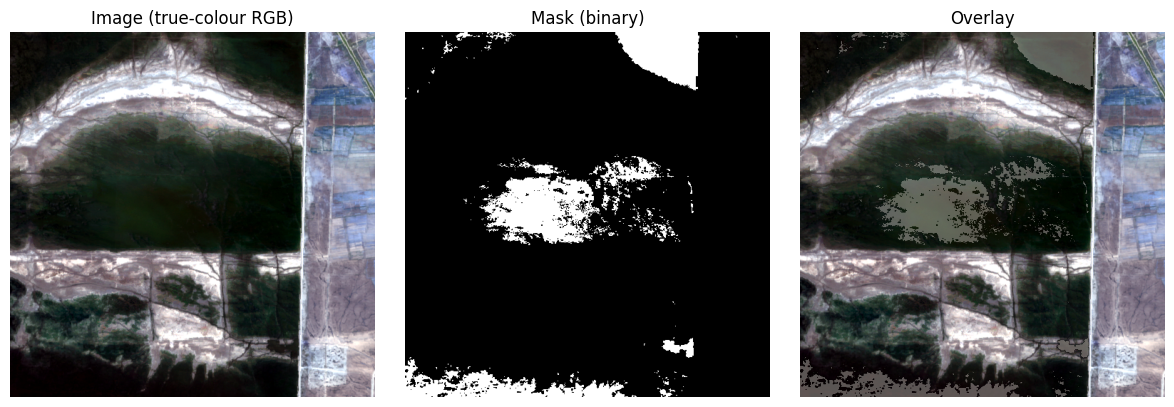

Image path: /content/Iraq_Marshes_s2_water_seg/training/rgb_png/central_marshes_2021_r004_c009.png
Mask path: /content/Iraq_Marshes_s2_water_seg/training/masks/central_marshes_2021_r004_c009.npy
Image shape: (512, 512, 3) dtype: uint8
Mask shape: (512, 512) dtype: uint8 mask min/max: 0 1
Water pixel ratio: 0.10550308227539062


In [65]:

base_dir = "/content/Iraq_Marshes_s2_water_seg"   # <-- note the leading /
split = "training"

img_fname  = "central_marshes_2021_r004_c009.png"
mask_fname = "central_marshes_2021_r004_c009.npy"

img_path  = os.path.join(base_dir, split, "rgb_png", img_fname)
mask_path = os.path.join(base_dir, split, "masks",  mask_fname)

print("Image exists?", os.path.exists(img_path), img_path)
print("Mask exists? ", os.path.exists(mask_path), mask_path)

img = np.array(Image.open(img_path))
mask = np.load(mask_path)

if mask.ndim == 3 and mask.shape[-1] == 1:
    mask = mask[..., 0]

# =========================
# TRUE-COLOUR RGB (assuming band order [B2,B3,B4,B8])
# =========================
# If your PNG is already 3-channel RGB, this step should change.
# If it's 4-channel (e.g., B2,B3,B4,B8), then:
if img.ndim == 3 and img.shape[-1] >= 3:
    # If it's 4-band: RGB = [B4,B3,B2] = indices [2,1,0]
    rgb = img[..., [2, 1, 0]]
else:
    raise ValueError(f"Unexpected image shape: {img.shape}")

rgb_disp = np.zeros_like(rgb, dtype=np.float32)
for c in range(3):
    p2, p98 = np.percentile(rgb[..., c], (2, 98))
    rgb_disp[..., c] = np.clip((rgb[..., c] - p2) / (p98 - p2 + 1e-6), 0, 1)

# =========================
# MASK -> BINARY
# =========================
m = mask.astype(np.float32)
if m.max() > 1.5:  # e.g., 0/255
    m = m / 255.0
m_bin = (m > 0.5).astype(np.uint8)

# =========================
# PLOT
# =========================
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(rgb_disp)
plt.title("Image (true-colour RGB)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(m_bin, cmap="gray")
plt.title("Mask (binary)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(rgb_disp)
plt.imshow(np.ma.masked_where(m_bin == 0, m_bin), cmap="Reds", alpha=0.35)
plt.title("Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Image path:", img_path)
print("Mask path:", mask_path)
print("Image shape:", img.shape, "dtype:", img.dtype)
print("Mask shape:", mask.shape, "dtype:", mask.dtype, "mask min/max:", mask.min(), mask.max())
print("Water pixel ratio:", float(m_bin.mean()))

# Functions

In [66]:
'''
  Returns an image plot of mask prediction
'''

def reconstruct_image(model, image, rounded=False):

  # Find model prediction
  reconstruction = model.predict(image).reshape(image.shape[1], image.shape[2])
  # Standardise between 0-1
  reconstruction = reconstruction/np.max(reconstruction)

  # Round to 0-1, binary pixel-by-pixel classification
  if rounded:
    reconstruction = np.round(reconstruction)

  # Plot reconstructed mask (prediction)
  plt.imshow(reconstruction)

In [67]:
'''
  Returns array of mask prediction, given model and image
'''
def reconstruct_array(model, image, rounded=False):

  # Find model prediction
  reconstruction = model.predict(image).reshape(image.shape[1], image.shape[2])

  if rounded:
    reconstruction = np.round(reconstruction)

  return reconstruction # Returns array

In [68]:
'''
  Metric functions for evaluation
'''

def score_eval(model, image, mask): # Gives score of mask vs prediction
  if type(image) != list:
    reconstruction = model.predict(image).reshape(mask.shape[1], mask.shape[2])
    reconstruction = np.round(reconstruction).flatten()

    return accuracy_score(mask.flatten(), reconstruction)

  else: # If a list of images input, find accuracy for each
    scores = []
    for i in range(len(image)):
      reconstruction = model.predict(image[i].reshape(1, 512, 512, 3))
      reconstruction = np.round(reconstruction).flatten()

      scores.append(accuracy_score(mask[i].flatten(), reconstruction))

    return scores

def score_eval2(model, image, mask): # Gives score of mask vs prediction
  if type(image) != list:
    reconstruction = model.predict(image).reshape(mask.shape[1], mask.shape[2])
    reconstruction = np.round(reconstruction).flatten()

    return accuracy_score(mask.flatten(), reconstruction)

  else: # If a list of images input, find accuracy for each
    scores = []
    for i in range(len(image)):
      reconstruction = model.predict(image[i].reshape(1, 512, 512, 4))
      reconstruction = np.round(reconstruction).flatten()

      scores.append(accuracy_score(mask[i].flatten(), reconstruction))

    return scores

def recall_eval(model, image, mask): # Find recall score
  if type(image) != list:
    reconstruction = model.predict(image).reshape(mask.shape[1], mask.shape[2])
    reconstruction = np.round(reconstruction).flatten()

    return recall_score(mask.flatten(), reconstruction, average='weighted')

  else: # If a list of images input, find accuracy for each
    recall = []
    for i in range(len(image)):
        reconstruction = model.predict(image[i]).reshape(mask[i].shape[1], mask[i].shape[2])
        reconstruction = np.round(reconstruction).flatten()

        recall.append(recall_score(mask[i].flatten(), reconstruction, average='weighted'))

    return recall

def precision_eval(model, image, mask): # Find precision score
  if type(image) != list:
    reconstruction = model.predict(image).reshape(mask.shape[1], mask.shape[2])
    reconstruction = np.round(reconstruction).flatten()

    return precision_score(mask.flatten(), reconstruction, average='weighted')

  else: # If a list of images input, find accuracy for each
    precision = []
    for i in range(len(image)):
        reconstruction = model.predict(image[i]).reshape(mask[i].shape[1], mask[i].shape[2])
        reconstruction = np.round(reconstruction).flatten()

        precision.append(precision_score(mask[i].flatten(), reconstruction, average='weighted'))

    return precision

def f1_score_eval(model, image, mask): # Find F1-score
    prec = np.mean(precision_eval(model, image, mask))
    rec = np.mean(recall_eval(model, image, mask))

    if prec + rec == 0:
        return 0

    return 2 * (prec * rec) / (prec + rec)

def f1_score_eval_basic(precision, recall):
    prec = np.mean(precision)
    rec = np.mean(recall)

    if prec + rec == 0:
        return 0

    return 2 * (prec * rec) / (prec + rec)

def produce_mask(image): # Outputs rounded image (binary)
  return np.round(image)

# Ingest and Process RGB Dataset

In [69]:

base_dir = "/content/Iraq_Marshes_s2_water_seg"

# ---------- TRAIN ----------
train_rgb_dir  = os.path.join(base_dir, "training", "rgb_png")
train_mask_dir = os.path.join(base_dir, "training", "masks")

training_images_list = [n for n in os.listdir(train_rgb_dir) if not os.path.isdir(os.path.join(train_rgb_dir, n))]

training_images = []
training_masks  = []

for n in training_images_list:
    img_path  = os.path.join(train_rgb_dir, n)
    mask_name = os.path.splitext(n)[0] + ".npy"
    mask_path = os.path.join(train_mask_dir, mask_name)

    im = Image.open(img_path).convert("RGB")
    training_images.append(im)

    training_masks.append(np.load(mask_path))


# ---------- VALIDATION ----------
val_rgb_dir  = os.path.join(base_dir, "validation", "rgb_png")
val_mask_dir = os.path.join(base_dir, "validation", "masks")

validation_images_list = [n for n in os.listdir(val_rgb_dir) if not os.path.isdir(os.path.join(val_rgb_dir, n))]

validation_images = []
validation_masks  = []

for n in validation_images_list:
    img_path  = os.path.join(val_rgb_dir, n)
    mask_name = os.path.splitext(n)[0] + ".npy"
    mask_path = os.path.join(val_mask_dir, mask_name)

    im = Image.open(img_path).convert("RGB")
    validation_images.append(im)

    validation_masks.append(np.load(mask_path))


# ---------- TEST ----------
test_rgb_dir = os.path.join(base_dir, "test", "rgb_png")
test_dir_fallback = os.path.join(base_dir, "test")
test_dir = test_rgb_dir if os.path.isdir(test_rgb_dir) else test_dir_fallback

test_images_list = [n for n in os.listdir(test_dir) if not os.path.isdir(os.path.join(test_dir, n))]

test_images = []
for n in test_images_list:
    path = os.path.join(test_dir, n)
    if n.lower().endswith(".npy"):
        im = np.load(path)
    else:
        im = Image.open(path).convert("RGB")
    test_images.append(im)

print("Train:", len(training_images), "Val:", len(validation_images), "Test:", len(test_images))
print("Example train img path:", os.path.join(train_rgb_dir, training_images_list[0]))

Train: 143 Val: 99 Test: 20
Example train img path: /content/Iraq_Marshes_s2_water_seg/training/rgb_png/central_marshes_2021_r007_c010.png


In [70]:
IMG_SIZE = 512

def to_pil_rgb(x):
    """Accept PIL.Image or np.ndarray and return a PIL RGB image."""
    if isinstance(x, Image.Image):
        return x.convert("RGB")

    if isinstance(x, np.ndarray):
        arr = x

        # If it's float in [0,1], convert to uint8
        if arr.dtype != np.uint8:
            # if values look like 0..1, scale up; otherwise clip
            if arr.max() <= 1.0:
                arr = (arr * 255.0).clip(0, 255).astype(np.uint8)
            else:
                arr = arr.clip(0, 255).astype(np.uint8)

        # Ensure 3 channels
        if arr.ndim == 2:
            arr = np.repeat(arr[..., None], 3, axis=-1)
        if arr.shape[-1] == 1:
            arr = np.repeat(arr, 3, axis=-1)
        if arr.shape[-1] > 3:
            arr = arr[..., :3]

        return Image.fromarray(arr, mode="RGB")

    raise TypeError(f"Unsupported type: {type(x)}")

def preprocess_img_any(x, size=IMG_SIZE):
    im = to_pil_rgb(x)
    im = im.resize((size, size), resample=Image.BILINEAR)
    return (np.asarray(im, dtype=np.float32) / 255.0)  # (512,512,3)

def preprocess_mask_npy(mask, size=IMG_SIZE):
    y = np.asarray(mask)
    if y.ndim == 3 and y.shape[-1] == 1:
        y = y[..., 0]

    # binarise (handles 0/255 or 0/1)
    y = (y > 0).astype(np.uint8)

    if y.shape[0] != size or y.shape[1] != size:
        y_img = Image.fromarray(y)
        y_img = y_img.resize((size, size), resample=Image.NEAREST)
        y = np.asarray(y_img, dtype=np.uint8)

    return y[..., None]  # (512,512,1)

# ---- apply ----
training_images   = [preprocess_img_any(im) for im in training_images]
validation_images = [preprocess_img_any(im) for im in validation_images]

training_masks    = [preprocess_mask_npy(m) for m in training_masks]
validation_masks  = [preprocess_mask_npy(m) for m in validation_masks]

# Stack into arrays
X_train = np.stack(training_images, axis=0)
Y_train = np.stack(training_masks,  axis=0)
X_val   = np.stack(validation_images, axis=0)
Y_val   = np.stack(validation_masks,  axis=0)

print("X_train:", X_train.shape, X_train.dtype, "range:", (X_train.min(), X_train.max()))
print("Y_train:", Y_train.shape, Y_train.dtype, "unique:", np.unique(Y_train)[:10])
print("X_val  :", X_val.shape, X_val.dtype)
print("Y_val  :", Y_val.shape, Y_val.dtype)

X_train: (143, 512, 512, 3) float32 range: (np.float32(0.0), np.float32(1.0))
Y_train: (143, 512, 512, 1) uint8 unique: [0 1]
X_val  : (99, 512, 512, 3) float32
Y_val  : (99, 512, 512, 1) uint8


In [71]:
print("Train image:", np.array(training_images[0]).shape)
print("Train mask :", np.array(training_masks[0]).shape, np.unique(training_masks[0])[:10])


Train image: (512, 512, 3)
Train mask : (512, 512, 1) [0 1]


In [72]:
# Create TensorFlow datasets for validation sets
validation_df = tf.data.Dataset.from_tensor_slices((validation_images, validation_masks))

In [73]:
#
# Data loader/generator from: https://github.com/bragagnololu/UNet-defmapping.git
#

def adjustData(img, mask, num_class):

    mask[mask > 0.5] = 1 # FOREST
    mask[mask <= 0.5] = 0 # NON-FOREST

    return (img,mask)

def trainGenerator(batch_size,
                   image_array,
                   mask_array,
                   aug_dict,
                   image_save_prefix  = "image",
                   mask_save_prefix  = "mask",
                   num_class = 2,
                   save_to_dir = None,
                   target_size = (512,512),
                   seed = 1):

    image_datagen = ImageDataGenerator(**aug_dict)
    mask_datagen = ImageDataGenerator(**aug_dict)

    image_generator = image_datagen.flow(image_array,
                                           batch_size = batch_size,
                                           save_to_dir = save_to_dir,
                                           save_prefix = image_save_prefix,
                                           seed = seed)

    mask_generator = mask_datagen.flow(mask_array,
                                           batch_size = batch_size,
                                           save_to_dir = save_to_dir,
                                           save_prefix = mask_save_prefix,
                                           seed = seed)

    train_generator = zip(image_generator, mask_generator)

    for (img,mask) in train_generator:
        img, mask = adjustData(img, mask, num_class)
        yield (img, mask)

In [74]:
#
# Produce generators for training images
#

t_images = np.stack(training_images)
t_masks = np.stack(training_masks)

v_images = np.stack(validation_images)
v_masks = np.stack(validation_masks)

# Set parameters for data augmentation
data_gen_args = dict(rotation_range=180,
                    width_shift_range=0.25,
                    height_shift_range=0.25,
                    shear_range=0.25,
                    zoom_range=0.25,
                    horizontal_flip=True,
                    vertical_flip = True,
                    fill_mode='reflect',
                    )

train = trainGenerator(1, t_images, t_masks, data_gen_args, save_to_dir=None)

# Ingest and Process 4-band Datasets

## 4-band Marshes dataset

In [75]:
base_dir2 = r"./content/Iraq_Marshes_s2_water_seg/"

In [79]:

# --- FIX BASE DIR (note leading /) ---
base_dir2 = "/content/Iraq_Marshes_s2_water_seg/"   # keep trailing slash or not; join handles both

# Ingest images and normalise
def minmax_norm(a, eps=1e-8):
    a = a.astype(np.float32)
    amin = np.min(a)
    amax = np.max(a)
    return (a - amin) / (amax - amin + eps)

def ensure_mask_hw1(m):
    m = np.array(m)
    # squeeze common odd shapes
    if m.ndim == 3 and m.shape[-1] == 1:
        return m.astype(np.int32)
    if m.ndim == 3 and m.shape[0] == 1:
        m = m[0]
    if m.ndim == 2:
        m = m[..., None]
    return m.astype(np.int32)

def only_npy(files):
    return [f for f in files if f.lower().endswith(".npy")]

def list_npy(dirpath, limit=None):
    print("Looking in:", dirpath)
    print("Exists?", os.path.isdir(dirpath))
    if not os.path.isdir(dirpath):
        # show parent directory to reveal actual folder names
        parent = os.path.dirname(dirpath.rstrip("/"))
        print("Parent:", parent, "exists?", os.path.isdir(parent))
        if os.path.isdir(parent):
            print("Parent contents (first 30):", sorted(os.listdir(parent))[:30])
        raise FileNotFoundError(f"Missing directory: {dirpath}")
    files = only_npy(os.listdir(dirpath))
    files = sorted(files)
    return files[:limit] if limit else files

# =========================
# TRAIN (4-band)
# =========================
train_img_dir  = os.path.join(base_dir2, "training", "images")
train_mask_dir = os.path.join(base_dir2, "training", "masks")

training_images_list2 = list_npy(train_img_dir, limit=250)
training_images2, training_masks2 = [], []

for n in training_images_list2:
    img = np.load(os.path.join(train_img_dir, n))   # (H,W,4)
    img = minmax_norm(img)
    training_images2.append(img)

    m = np.load(os.path.join(train_mask_dir, n))    # (H,W) or (H,W,1)
    training_masks2.append(ensure_mask_hw1(m))

# =========================
# VALIDATION (4-band)
# =========================
val_img_dir  = os.path.join(base_dir2, "validation", "images")
val_mask_dir = os.path.join(base_dir2, "validation", "masks")

validation_images_list2 = list_npy(val_img_dir)
validation_images2, validation_masks2 = [], []

for n in validation_images_list2:
    img = np.load(os.path.join(val_img_dir, n))
    img = minmax_norm(img)
    validation_images2.append(img)

    m = np.load(os.path.join(val_mask_dir, n))
    validation_masks2.append(ensure_mask_hw1(m))

# =========================
# TEST (4-band)
# =========================
test_img_dir  = os.path.join(base_dir2, "test", "images")
test_mask_dir = os.path.join(base_dir2, "test", "masks")

test_images_list2 = list_npy(test_img_dir)
test_images2, test_masks2 = [], []

for n in test_images_list2:
    img = np.load(os.path.join(test_img_dir, n))
    img = minmax_norm(img)
    test_images2.append(img)

    m = np.load(os.path.join(test_mask_dir, n))
    test_masks2.append(ensure_mask_hw1(m))

# =========================
# Verify
# =========================
print("Training image shape:", training_images2[0].shape, "dtype:", training_images2[0].dtype)
print("Training mask shape:", training_masks2[0].shape, "dtype:", training_masks2[0].dtype)
print("Counts:", len(training_images2), len(validation_images2), len(test_images2))

Looking in: /content/Iraq_Marshes_s2_water_seg/training/images
Exists? True
Looking in: /content/Iraq_Marshes_s2_water_seg/validation/images
Exists? True
Looking in: /content/Iraq_Marshes_s2_water_seg/test/images
Exists? True
Training image shape: (512, 512, 4) dtype: float32
Training mask shape: (512, 512, 1) dtype: int32
Counts: 143 99 20


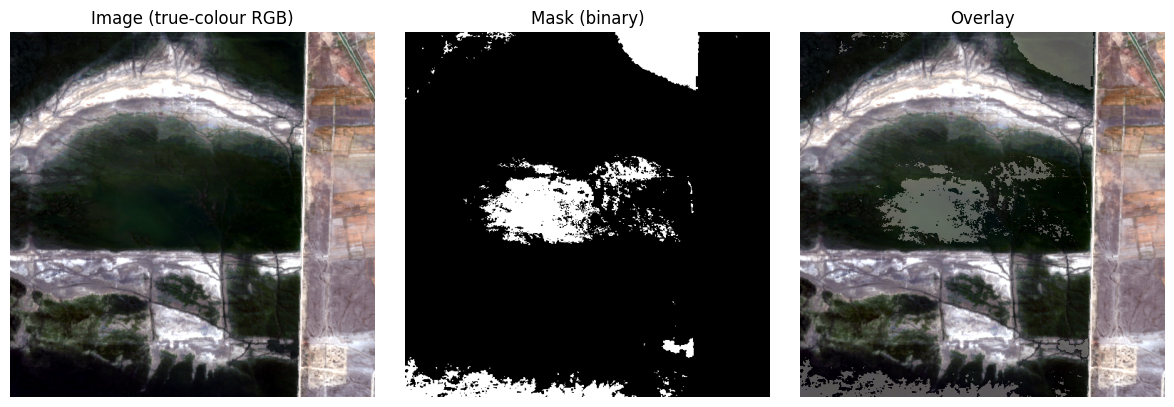

Image shape: (512, 512, 4) dtype: float32
Mask shape: (512, 512) dtype: uint8 mask min/max: 0 1
Water pixel ratio: 0.10550308227539062


In [80]:
fname = "central_marshes_2021_r004_c009.npy"
base_dir = "/content/Iraq_Marshes_s2_water_seg"
split = "training"
# =========================
# 2) LOAD ONE TILE
# =========================

img_path  = os.path.join(base_dir, split, "images", fname)
mask_path = os.path.join(base_dir, split, "masks",  fname)

img  = np.load(img_path).astype(np.float32)  # (H,W,4)
mask = np.load(mask_path)

# masks might be (H,W,1)
if mask.ndim == 3 and mask.shape[-1] == 1:
    mask = mask[..., 0]

# =========================
# 3) MAKE TRUE-COLOUR RGB (B4,B3,B2) + PER-CHANNEL STRETCH
# =========================
# Assuming band order is [B2,B3,B4,B8] -> RGB = [B4,B3,B2] = indices [2,1,0]
rgb = img[..., [2, 1, 0]]

rgb_disp = np.zeros_like(rgb, dtype=np.float32)
for c in range(3):
    p2, p98 = np.percentile(rgb[..., c], (2, 98))
    rgb_disp[..., c] = np.clip((rgb[..., c] - p2) / (p98 - p2 + 1e-6), 0, 1)

# =========================
# 4) MASK -> BINARY
# =========================
m = mask.astype(np.float32)
if m.max() > 1.5:  # e.g., 0/255
    m = m / 255.0
m_bin = (m > 0.5).astype(np.uint8)

# =========================
# 5) PLOT
# =========================
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(rgb_disp)
plt.title("Image (true-colour RGB)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(m_bin, cmap="gray")
plt.title("Mask (binary)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(rgb_disp)
plt.imshow(np.ma.masked_where(m_bin == 0, m_bin), cmap="Reds", alpha=0.35)
plt.title("Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Image shape:", img.shape, "dtype:", img.dtype)
print("Mask shape:", mask.shape, "dtype:", mask.dtype, "mask min/max:", mask.min(), mask.max())
print("Water pixel ratio:", float(m_bin.mean()))

In [81]:
#Preporcess
# --- helpers ---
def to_rgb4_512(pil_or_arr):
  """Return float32 array (512,512,4) in [0,1]. Pads/crops as needed."""
  x = np.array(pil_or_arr)

  # ensure channel dim
  if x.ndim == 2:
    x = x[..., None]

  # if RGB -> add alpha channel
  if x.shape[-1] == 3:
    alpha = np.full((x.shape[0], x.shape[1], 1), 255, dtype=x.dtype)
    x = np.concatenate([x, alpha], axis=-1)
  elif x.shape[-1] == 1:
    x = np.repeat(x, 4, axis=-1)
  elif x.shape[-1] >= 4:
    x = x[..., :4]

  # crop/pad to 512x512
  H, W, C = x.shape
  x = x[:512, :512, :4]
  H2, W2, _ = x.shape

  if H2 < 512 or W2 < 512:
    out = np.zeros((512, 512, 4), dtype=x.dtype)
    out[:H2, :W2, :] = x
    x = out

  # normalise
  x = x.astype("float32") / 255.0
  return x

def mask_to_512_1(m):
  """Return int array (1,512,512,1). Pads/crops as needed."""
  y = np.array(m)

  # squeeze common shapes like (1,H,W) or (H,W,1)
  if y.ndim == 3 and y.shape[0] == 1:
    y = y[0]
  if y.ndim == 3 and y.shape[-1] == 1:
    y = y[..., 0]

  # now y should be (H,W)
  y = y[:512, :512]
  H, W = y.shape

  if H < 512 or W < 512:
    out = np.zeros((512, 512), dtype=y.dtype)
    out[:H, :W] = y
    y = out

  y = y.reshape(1, 512, 512, 1).astype("int")
  return y

# =========================
# FIXED "NUMBER 2" PIPELINE
# =========================

# TRAIN IMAGES
for i in range(len(training_images2)):
  x = to_rgb4_512(training_images2[i])   # (512,512,4)
  x = x.T                                # (4,512,512)
  training_images2[i] = x.reshape(-1, 512, 512, 4)  # (1,512,512,4)

# TRAIN MASKS
for i in range(len(training_masks2)):
  y = mask_to_512_1(training_masks2[i])  # (1,512,512,1)
  training_masks2[i] = y.T               # matches your style

# VALIDATION IMAGES
for i in range(len(validation_images2)):
  x = to_rgb4_512(validation_images2[i])
  x = x.T
  validation_images2[i] = x.reshape(-1, 512, 512, 4)

# VALIDATION MASKS
for i in range(len(validation_masks2)):
  y = mask_to_512_1(validation_masks2[i])
  validation_masks2[i] = y.T

# TEST IMAGES
for i in range(len(test_images2)):
  x = to_rgb4_512(test_images2[i])
  x = x.T
  test_images2[i] = x.reshape(-1, 512, 512, 4)

# OPTIONAL: only if you actually have test masks loaded somewhere
if "test_masks2" in globals():
  for i in range(len(test_masks2)):
    y = mask_to_512_1(test_masks2[i])
    test_masks2[i] = y.T


In [ ]:
# Plot example training image first band
plt.imshow(training_images2[3].reshape(512,512,4)[:,:,0])

In [82]:
# Create TensorFlow datasets for training and validation sets
train_df_4band_marshes = tf.data.Dataset.from_tensor_slices((training_images2[0:250], training_masks2[0:250]))
validation_df_4band_marshes = tf.data.Dataset.from_tensor_slices((validation_images2, validation_masks2))

## 4-band Lake dataset

In [83]:
# Specify whether to download data or read in
download = True
base_dir3 = "/content/Iraq_Lake_s2_water_seg/"

In [84]:
# Download data (Atlantic Forest)
if download:
    # Download data
    url = "https://zenodo.org/records/18471652/files/Iraq_Lake_s2_water_seg.zip?download=11"

    # download
    r = requests.get(url)
    with open("data.zip", "wb") as f:
        f.write(r.content)

    # extract
    with zipfile.ZipFile("data.zip", "r") as z:
        z.extractall("/content/")

    # confirm
    os.listdir("/content/")


In [86]:
# =========================
# TRAIN (4-band)
# =========================
training_images_list3 = only_npy(os.listdir(rf"{base_dir3}training/images/"))[:250]
training_masks_list3  = training_images_list3[:]   # same filenames
training_images3 = []
training_masks3  = []

for n in training_images_list3:
    img = np.load(rf"{base_dir3}training/images/{n}")
    img = minmax_norm(img)
    training_images3.append(img)

    m = np.load(rf"{base_dir3}training/masks/{n}")
    training_masks3.append(ensure_mask_hw1(m))

# =========================
# VALIDATION (4-band)
# =========================
validation_images_list3 = only_npy(os.listdir(rf"{base_dir3}validation/images/"))
validation_masks_list3  = validation_images_list3[:]
validation_images3 = []
validation_masks3  = []

for n in validation_images_list3:
    img = np.load(rf"{base_dir3}validation/images/{n}")
    img = minmax_norm(img)
    validation_images3.append(img)

    m = np.load(rf"{base_dir3}validation/masks/{n}")
    validation_masks3.append(ensure_mask_hw1(m))

# =========================
# TEST (4-band)
# =========================
test_images_list3 = only_npy(os.listdir(rf"{base_dir3}test/images/"))
test_masks_list3  = test_images_list3[:]
test_images3 = []
test_masks3  = []

for n in test_images_list3:
    img = np.load(rf"{base_dir3}test/images/{n}")
    img = minmax_norm(img)
    test_images3.append(img)

    m = np.load(rf"{base_dir3}test/masks/{n}")
    test_masks3.append(ensure_mask_hw1(m))

# =========================
# Verify
# =========================
print("Training image shape:", training_images3[0].shape, "dtype:", training_images3[0].dtype)
print("Training mask shape:", training_masks3[0].shape, "dtype:", training_masks3[0].dtype)
print("Counts:", len(training_images3), len(validation_images3), len(test_images3))


Training image shape: (512, 512, 4) dtype: float32
Training mask shape: (512, 512, 1) dtype: int32
Counts: 250 56 20


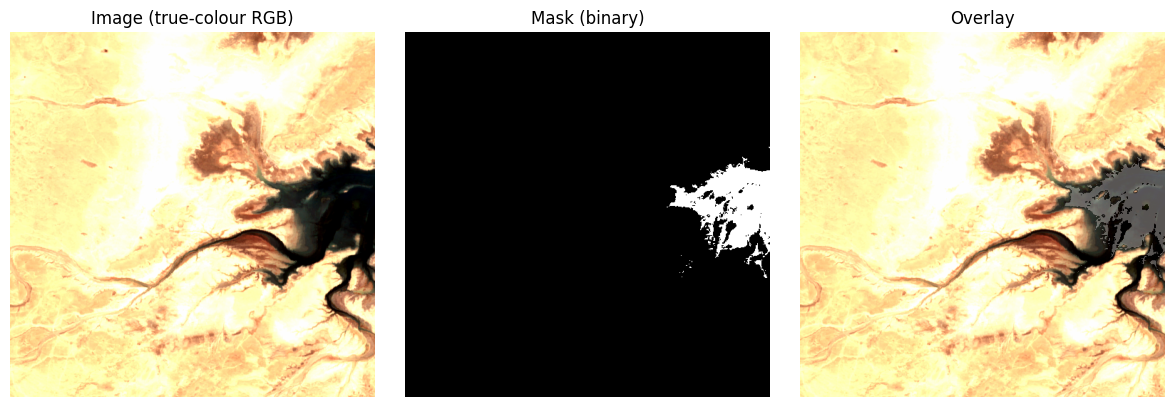

Image shape: (512, 512, 4) dtype: float32
Mask shape: (512, 512) dtype: uint8 mask min/max: 0 1
Water pixel ratio: 0.03725433349609375


In [87]:
# Show example train image

fname = "tharthar_2021_r015_c008.npy"
split = "training"
# =========================
# 2) LOAD ONE TILE
# =========================

img_path  = os.path.join(base_dir3, split, "images", fname)
mask_path = os.path.join(base_dir3, split, "masks",  fname)

img  = np.load(img_path).astype(np.float32)  # (H,W,4)
mask = np.load(mask_path)

# masks might be (H,W,1)
if mask.ndim == 3 and mask.shape[-1] == 1:
    mask = mask[..., 0]

# =========================
# 3) MAKE TRUE-COLOUR RGB (B4,B3,B2) + PER-CHANNEL STRETCH
# =========================
# Assuming band order is [B2,B3,B4,B8] -> RGB = [B4,B3,B2] = indices [2,1,0]
rgb = img[..., [2, 1, 0]]

rgb_disp = np.zeros_like(rgb, dtype=np.float32)
for c in range(3):
    p2, p98 = np.percentile(rgb[..., c], (2, 98))
    rgb_disp[..., c] = np.clip((rgb[..., c] - p2) / (p98 - p2 + 1e-6), 0, 1)

# =========================
# 4) MASK -> BINARY
# =========================
m = mask.astype(np.float32)
if m.max() > 1.5:  # e.g., 0/255
    m = m / 255.0
m_bin = (m > 0.5).astype(np.uint8)

# =========================
# 5) PLOT
# =========================
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(rgb_disp)
plt.title("Image (true-colour RGB)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(m_bin, cmap="gray")
plt.title("Mask (binary)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(rgb_disp)
plt.imshow(np.ma.masked_where(m_bin == 0, m_bin), cmap="Reds", alpha=0.35)
plt.title("Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Image shape:", img.shape, "dtype:", img.dtype)
print("Mask shape:", mask.shape, "dtype:", mask.dtype, "mask min/max:", mask.min(), mask.max())
print("Water pixel ratio:", float(m_bin.mean()))

In [88]:
# Pre-process data, reshaping and transposing
for i in range(len(training_images3)):
  training_images3[i] = training_images3[i].astype('float32')
  training_images3[i] = training_images3[i].T

for i in range(len(training_masks3)):
  training_masks3[i] = training_masks3[i].reshape(1,512,512,1)
  training_masks3[i] = training_masks3[i].T

for i in range(len(validation_images3)):
  validation_images3[i] = validation_images3[i].astype('float32')
  validation_images3[i] = validation_images3[i].T

for i in range(len(validation_masks3)):
  validation_masks3[i] = validation_masks3[i].reshape(1,512,512,1)
  validation_masks3[i] = validation_masks3[i].T

for i in range(len(test_images3)):
  test_images3[i] = test_images3[i].astype('float32')
  test_images3[i] = test_images3[i].T

for i in range(len(test_masks3)):
  test_masks3[i] = test_masks3[i].reshape(1,512,512,1)
  test_masks3[i] = test_masks3[i].T


for i in range(len(training_images3)):
  training_images3[i] = training_images3[i].reshape(-1,512,512,4)

for i in range(len(validation_images3)):
  validation_images3[i] = validation_images3[i].reshape(-1,512,512,4)

for i in range(len(test_images3)):
  test_images3[i] = test_images3[i].reshape(-1,512,512,4)

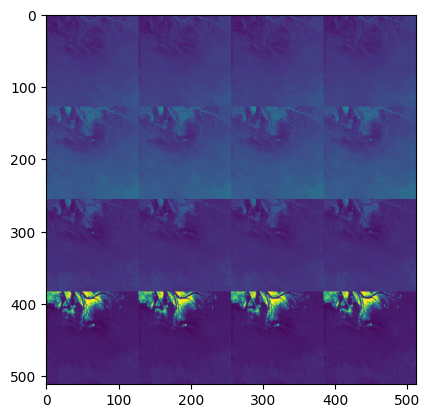

In [89]:
# Plot example training image first band
plt.imshow(training_images3[0].reshape(512,512,4)[:,:,0])

In [ ]:
# Create TensorFlow datasets for training and validation sets
train_df_4band_lakes = tf.data.Dataset.from_tensor_slices((training_images3[0:250], training_masks3[0:250]))
validation_df_4band_lakes = tf.data.Dataset.from_tensor_slices((validation_images3, validation_masks3))

# Models

## U-Net

In [ ]:
'''
  Convolutional block with set parameters and activation layer after
'''

def convBlock(input, filters, kernel, kernel_init='he_normal', act='relu', transpose=False):
  if transpose == False:
    #conv = ZeroPadding2D((1,1))(input)
    conv = Conv2D(filters, kernel, padding = 'same', kernel_initializer = kernel_init)(input)
  else:
    #conv = ZeroPadding2D((1,1))(input)
    conv = Conv2DTranspose(filters, kernel, padding = 'same', kernel_initializer = kernel_init)(input)

  conv = Activation(act)(conv)
  return conv

'''
  U-Net model
'''

def UNet(trained_weights = None, input_size = (512,512,4), drop_rate = 0.25, lr=0.0001):

    ## Can add pretrained weights by specifying 'trained_weights'

    # Input layer
    inputs = Input(input_size, batch_size=1)

    ## Contraction phase
    conv1 = convBlock(inputs, 64, 3)
    conv1 = convBlock(conv1, 64, 3)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = convBlock(pool1, 128, 3)
    conv2 = convBlock(conv2, 128, 3)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)
    #drop2 = Dropout(drop_rate)(pool2)

    conv3 = convBlock(pool2, 256, 3)
    conv3 = convBlock(conv3, 256, 3)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)
    #drop3 = Dropout(drop_rate)(pool3)

    conv4 = convBlock(pool3, 512, 3)
    conv4 = convBlock(conv4, 512, 3)
    pool4 = MaxPooling2D(pool_size=(2, 2))(conv4)
    #drop4 = Dropout(drop_rate)(pool4)

    conv5 = convBlock(pool4, 1024, 3)
    conv5 = convBlock(conv5, 1024, 3)

    ## Expansion phase
    up6 = (Conv2DTranspose(512, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv5))
    merge6 = concatenate([conv4,up6])
    conv6 = convBlock(merge6, 512, 3)
    conv6 = convBlock(conv6, 512, 3)
    #conv6 = Dropout(drop_rate)(conv6)

    up7 = (Conv2DTranspose(256, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv6))
    merge7 = concatenate([conv3,up7])
    conv7 = convBlock(merge7, 256, 3)
    conv7 = convBlock(conv7, 256, 3)
    #conv7 = Dropout(drop_rate)(conv7)

    up8 = (Conv2DTranspose(128, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv7))
    merge8 = concatenate([conv2,up8])
    conv8 = convBlock(merge8, 128, 3)
    conv8 = convBlock(conv8, 128, 3)
    #conv8 = Dropout(drop_rate)(conv8)

    up9 = (Conv2DTranspose(64, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv8))
    merge9 = concatenate([conv1,up9])
    conv9 = convBlock(merge9, 64, 3)
    conv9 = convBlock(conv9, 64, 3)

    # Output layer
    conv10 = convBlock(conv9, 1, 1, act='sigmoid')

    model = Model(inputs, conv10)

    model.compile(optimizer = Adam(learning_rate = lr), loss = 'binary_crossentropy', metrics = ['accuracy', 'mse'])

    if trained_weights != None:
    	model.load_weights(trained_weights)

    return model

In [ ]:
# Print model layers and number of parameters
UNet().summary()

## Attention U-Net

In [ ]:
'''
  Convolutional block with two conv layers and two activation layers
'''

def convBlock2(input, filters, kernel, kernel_init='he_normal', act='relu', transpose=False):
  if transpose == False:
    conv = Conv2D(filters, kernel, padding = 'same', kernel_initializer = kernel_init)(input)
    conv = Activation(act)(conv)
    conv = Conv2D(filters, kernel, padding = 'same', kernel_initializer = kernel_init)(conv)
    conv = Activation(act)(conv)
  else:
    conv = Conv2DTranspose(filters, kernel, padding = 'same', kernel_initializer = kernel_init)(input)
    conv = Activation(act)(conv)
    conv = Conv2DTranspose(filters, kernel, padding = 'same', kernel_initializer = kernel_init)(conv)
    conv = Activation(act)(conv)

  return conv

'''
  Attention block/mechanism
'''
def attention_block(x, gating, inter_shape, drop_rate=0.25):

    # Find shape of inputs
    shape_x = K.int_shape(x)
    shape_g = K.int_shape(gating)

    ## Process x vector and gating signal
    # x vector input and processing
    theta_x = Conv2D(inter_shape, kernel_size = 1, strides = 1, padding='same', kernel_initializer='he_normal', activation=None)(x)
    theta_x = MaxPooling2D((2,2))(theta_x)
    shape_theta_x = K.int_shape(theta_x)

    # gating signal ""
    phi_g = Conv2D(inter_shape, kernel_size = 1, strides = 1, padding='same', kernel_initializer='he_normal', activation=None)(gating)
    shape_phi_g = K.int_shape(phi_g)

    # Add components
    concat_xg = add([phi_g, theta_x])
    act_xg = Activation('relu')(concat_xg)

    # Apply convolution
    psi = Conv2D(1, kernel_size = 1, strides = 1, padding='same', kernel_initializer='he_normal', activation=None)(act_xg)

    # Apply sigmoid activation
    sigmoid_xg = Activation('sigmoid')(psi)
    shape_sigmoid = K.int_shape(sigmoid_xg)

    # UpSample and resample to correct size
    upsample_psi = UpSampling2D(interpolation='bilinear', size=(shape_x[1] // shape_sigmoid[1], shape_x[2] // shape_sigmoid[2]))(sigmoid_xg)
    y = multiply([upsample_psi, x])

    return y


'''
  Attention U-Net model
'''

def UNetAM(trained_weights = None, input_size = (512,512,3), drop_rate = 0.25, lr=0.0001, filter_base=16):

    ## Can add pretrained weights by specifying 'trained_weights'

    # Input layer
    inputs = Input(input_size, batch_size=1)

    ## Contraction phase
    conv = convBlock2(inputs, filter_base, 3)
    #conv0 = Dropout(drop_rate)(conv0)

    conv0 = MaxPooling2D(pool_size=(2, 2))(conv)
    conv0 = convBlock2(conv0, 2 * filter_base, 3)

    pool0 = MaxPooling2D(pool_size=(2, 2))(conv0)
    conv1 = convBlock2(pool0, 4 * filter_base, 3)
    #conv1 = Dropout(drop_rate)(conv1)

    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)
    conv2 = convBlock2(pool1, 8 * filter_base, 3)
    #conv2 = Dropout(drop_rate)(conv2)

    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)
    conv3 = convBlock2(pool2, 16 * filter_base, 3)
    #conv3 = Dropout(drop_rate)(conv3)

    ## Expansion phase
    up4 = (Conv2DTranspose(8 * filter_base, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv3))
    merge4 = attention_block(conv2, conv3, 8 * filter_base, drop_rate) # Attention gate
    conv4 = concatenate([up4, merge4])
    conv4 = convBlock2(conv4, 8 * filter_base, 3)

    up5 = (Conv2DTranspose(4 * filter_base, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv4))
    merge5 = attention_block(conv1, conv4, 4 * filter_base, drop_rate) # Attention gate
    conv5 = concatenate([up5, merge5])
    conv5 = convBlock2(conv5, 4 * filter_base, 3)

    up6 = (Conv2DTranspose(2 * filter_base, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv5))
    merge6 = attention_block(conv0, conv5, 2 * filter_base, drop_rate) # Attention gate
    conv6 = concatenate([up6, merge6])
    conv6 = convBlock2(conv6, 2 * filter_base, 3)

    up7 = (Conv2DTranspose(1 * filter_base, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv6))
    merge7 = attention_block(conv, conv6, 1 * filter_base, drop_rate) # Attention gate
    conv7 = concatenate([up7, merge7])
    conv7 = concatenate([up7, conv])
    conv7 = convBlock2(conv7, 1 * filter_base, 3)

    ## Output layer
    out = convBlock(conv7, 1, 1, act='sigmoid')

    model = Model(inputs, out)

    model.compile(optimizer = Adam(learning_rate = lr), loss = binary_crossentropy, metrics = ['accuracy', 'mse'])

    if trained_weights != None:
    	model.load_weights(trained_weights)

    return model

In [ ]:
# Print model layers and number of parameters
UNetAM().summary()

# Train on RGB feature data

## U-Net

In [ ]:
# Train U-Net with generator
model_unet = UNet(input_size=(512,512,3), lr=0.0001)
save_model = ModelCheckpoint('unet-3d.keras', monitor='val_accuracy',verbose=1, save_best_only=True)
train = trainGenerator(1, t_images, t_masks, data_gen_args, save_to_dir=None)

model_unet.fit(train, steps_per_epoch=100, epochs=30, validation_data = validation_df, callbacks=[save_model])

In [ ]:
# Save model training history
np.save('unet-3d-history.npy',model_unet.history.history)

In [ ]:
# Copy models to drive
!cp unet-3d.keras drive/MyDrive/Diss/
!cp unet-3d-history.npy drive/MyDrive/Diss/

In [ ]:
# Plot accuracy and loss

## Accuracy
plt.plot(model_unet.history.history['accuracy'])
plt.plot(model_unet.history.history['val_accuracy'])
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')
plt.show()

## Loss
plt.plot(model_unet.history.history['loss'])
plt.plot(model_unet.history.history['val_loss'])
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')

## Attention U-Net

In [ ]:
# Train Attention U-Net with generator
model_attention_unet = UNetAM(lr=0.0005, filter_base=16)
save_model_am = ModelCheckpoint('unet-attention-3d.keras', monitor='val_accuracy',verbose=1, save_best_only=True)
train = trainGenerator(1, t_images, t_masks, data_gen_args, save_to_dir=None)
model_attention_unet.fit(train, steps_per_epoch=100, epochs=50, validation_data = validation_df, callbacks=[save_model_am])

In [ ]:
# Save model history
np.save('unet-attention-3d-history.npy',model_attention_unet.history.history)

In [ ]:
# Copy models to drive
!cp unet-attention-3d.keras drive/MyDrive/Diss/
!cp unet-attention-3d-history.npy drive/MyDrive/Diss/

# Train on 4-band data

## Train on 4-band Amazon data

### U-Net

In [ ]:
# Train U-Net with generator
model_unet_4band = UNet()
save_model_4band = ModelCheckpoint('unet-4d.keras', monitor='val_accuracy',verbose=1, save_best_only=True)
model_unet_4band.fit(train_df_4band_amazon, epochs = 20, validation_data = validation_df_4band_amazon, callbacks=[save_model_4band])

In [ ]:
# Save model history
np.save('unet-4d-history.npy',model_unet_4band.history.history)

In [ ]:
# Copy models to drive
!cp unet-4d.keras drive/MyDrive/Diss/
!cp unet-4d-history.npy drive/MyDrive/Diss/

### Attention U-Net

In [ ]:
# Train U-Net with generator
model_attention_unet_4band = UNetAM(input_size=(512,512,4), filter_base=16, lr=0.0005)
save_model_4band_attention = ModelCheckpoint('unet-attention-4d.keras', monitor='val_accuracy',verbose=1, save_best_only=True)
model_attention_unet_4band.fit(train_df_4band_amazon, epochs = 60, validation_data = validation_df_4band_amazon, callbacks=[save_model_4band_attention])

In [ ]:
# Save model history
np.save('unet-attention-4d-history.npy',model_attention_unet_4band.history.history)

In [ ]:
# Copy models to drive
!cp unet-attention-4d.keras drive/MyDrive/Diss/
!cp unet-attention-4d-history.npy drive/MyDrive/Diss/

## Train on 4-band Atlantic data

### U-Net

In [ ]:
# Train U-Net with generator
model_unet_4band_atlantic = UNet()
save_model_4band_atlantic = ModelCheckpoint('unet-4d-atlantic.keras', monitor='val_accuracy',verbose=1, save_best_only=True)
model_unet_4band_atlantic.fit(train_df_4band_atlantic, epochs = 20, validation_data = validation_df_4band_atlantic, callbacks=[save_model_4band_atlantic])

In [ ]:
# Save model history
np.save('unet-4d-atlantic-history.npy',model_unet_4band_atlantic.history.history)

In [ ]:
# Copy models to drive
!cp unet-4d-atlantic.hdf5 drive/MyDrive/Diss/
!cp unet-4d-atlantic-history.npy drive/MyDrive/Diss/

### Attention U-Net

In [ ]:
# Train Attention U-Net with generator
model_attention_unet_4band_atlantic = UNetAM(input_size=(512,512,4), filter_base=16, lr=0.0005)
save_model_4band_attention_atlantic = ModelCheckpoint('unet-attention-4d-atlantic.keras', monitor='val_accuracy',verbose=1, save_best_only=True)
model_attention_unet_4band_atlantic.fit(train_df_4band_atlantic, epochs = 60, validation_data = validation_df_4band_atlantic, callbacks=[save_model_4band_attention_atlantic])

In [ ]:
# Save model history
np.save('unet-attention-4d-atlantic-history.npy',model_attention_unet_4band_atlantic.history.history)

In [ ]:
# Copy models to drive
!cp unet-attention-4d-atlantic.hdf5 drive/MyDrive/Diss/
!cp unet-attention-4d-atlantic-history.npy drive/MyDrive/Diss/

# Import Models and Compute Metrics

## RGB

In [ ]:
# Load 3-dim models and history stats
attention_unet = load_model('unet-attention-3d.keras')
unet = load_model('unet-3d.keras')

unet_history = np.load('unet-3d-history.npy', allow_pickle='TRUE').item()
attention_unet_history = np.load('unet-attention-3d-history.npy', allow_pickle='TRUE').item()

In [ ]:
# Plot accuracy and loss for U-Net

## Accuracy
plt.plot(unet_history['accuracy'])
plt.plot(unet_history['val_accuracy'])
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')
plt.show()

## Loss
plt.plot(unet_history['loss'])
plt.plot(unet_history['val_loss'])
plt.ylabel('Loss', size=12)
plt.xlabel('Epoch', size=12)
plt.legend(['Training', 'Validation'], loc='lower right')

In [ ]:
# Plot accuracy and loss for Attention U-Net

## Accuracy
plt.plot(attention_unet_history['accuracy'])
plt.plot(attention_unet_history['val_accuracy'])
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show()

## Loss
plt.plot(attention_unet_history['loss'])
plt.plot(attention_unet_history['val_loss'])
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')

In [ ]:
# Scores of each model
unet_score = (score_eval(unet, validation_images, validation_masks))
am_unet_score = (score_eval(attention_unet, validation_images, validation_masks))

In [ ]:
# Precision and recall of each model
unet_precision = (precision_eval(unet, validation_images, validation_masks))
am_unet_precision = (precision_eval(attention_unet, validation_images, validation_masks))

unet_recall = (recall_eval(unet, validation_images, validation_masks))
am_unet_recall = (recall_eval(attention_unet, validation_images, validation_masks))

In [ ]:
# F1-scores of each model
unet_f1_score = (f1_score_eval_basic(unet_precision, unet_recall))
am_unet_f1_score = (f1_score_eval_basic(am_unet_precision, am_unet_recall))

In [ ]:
# Print score eval results for each model
print('U-Net accuracy: ', np.mean(unet_score), np.std(unet_score))
print('Attention U-Net accuracy: ', np.mean(am_unet_score), np.std(am_unet_score))

In [ ]:
# Print precision eval results for each model
print('U-Net precision: ', np.mean(unet_precision), np.std(unet_precision))
print('Attention U-Net precision: ', np.mean(am_unet_precision), np.std(am_unet_precision))

In [ ]:
# Print recall eval results for each model
print('U-Net recall: ', np.mean(unet_recall), np.std(unet_recall))
print('Attention U-Net recall: ', np.mean(am_unet_recall), np.std(am_unet_recall))

In [ ]:
# Print f1-score eval results for each model
print('U-Net F1-score: ', np.mean(unet_f1_score))
print('Attention U-Net F1-score: ', np.mean(am_unet_f1_score))

## 4-band

### Amazon Data

In [ ]:
# Load 4-dim models and history stats
attention_unet_4d = load_model('unet-attention-4d.keras')
unet_4d = load_model('unet-4d.keras')

unet_4d_history = np.load('unet-4d-history.npy', allow_pickle='TRUE').item()
attention_unet_4d_history = np.load('unet-attention-4d-history.npy', allow_pickle='TRUE').item()

In [ ]:
# Plot accuracy and loss for U-Net

## Accuracy
plt.plot(unet_4d_history['accuracy'])
plt.plot(unet_4d_history['val_accuracy'])
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')
plt.show()

## Loss
plt.plot(unet_4d_history['loss'])
plt.plot(unet_4d_history['val_loss'])
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')

In [ ]:
# Plot accuracy and loss for Attention U-Net

## Accuracy
plt.plot(attention_unet_4d_history['accuracy'])
plt.plot(attention_unet_4d_history['val_accuracy'])
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')
plt.show()

## Loss
plt.plot(attention_unet_4d_history['loss'])
plt.plot(attention_unet_4d_history['val_loss'])
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')

In [ ]:
# Scores of each model
unet_4d_score = (score_eval2(unet_4d, validation_images2, validation_masks2))
am_unet_4d_score = (score_eval2(attention_unet_4d, validation_images2, validation_masks2))

In [ ]:
# Precision and recall of each model
unet_4d_precision = (precision_eval(unet_4d, validation_images2, validation_masks2))
am_unet_4d_precision = (precision_eval(attention_unet_4d, validation_images2, validation_masks2))

unet_4d_recall = (recall_eval(unet_4d, validation_images2, validation_masks2))
am_unet_4d_recall = (recall_eval(attention_unet_4d, validation_images2, validation_masks2))

In [ ]:
# F1-scores of each model
unet_4d_f1_score = (f1_score_eval_basic(unet_4d_precision, unet_4d_recall))
am_unet_4d_f1_score = (f1_score_eval_basic(am_unet_4d_precision, am_unet_4d_recall))

In [ ]:
# Print score eval results for each model
print('U-Net accuracy: ', np.mean(unet_4d_score), np.std(unet_4d_score))
print('Attention U-Net accuracy: ', np.mean(am_unet_4d_score), np.std(am_unet_4d_score))

In [ ]:
# Print precision eval results for each model
print('U-Net precision: ', np.mean(unet_4d_precision), np.std(unet_4d_precision))
print('Attention U-Net precision: ', np.mean(am_unet_4d_precision), np.std(am_unet_4d_precision))

In [ ]:
# Print recall eval results for each model
print('U-Net recall: ', np.mean(unet_4d_recall), np.std(unet_4d_recall))
print('Attention U-Net recall: ', np.mean(am_unet_4d_recall), np.std(am_unet_4d_recall))

In [ ]:
# Print f1-score eval results for each model
print('U-Net F1-score: ', np.mean(unet_4d_f1_score))
print('Attention U-Net F1-score: ', np.mean(am_unet_4d_f1_score))

### Amazon on unseen Atlantic data

In [ ]:
# Score
unet_amazon_on_atlantic_score = score_eval2(unet_4d, validation_images3+test_images3, validation_masks3+test_masks3)
am_unet_amazon_on_atlantic_score = score_eval2(attention_unet_4d, validation_images3+test_images3, validation_masks3+test_masks3)

# Precision
unet_amazon_on_atlantic_precision = (precision_eval(unet_4d, validation_images3+test_images3, validation_masks3+test_masks3))
am_unet_amazon_on_atlantic_precision = (precision_eval(attention_unet_4d, validation_images3+test_images3, validation_masks3+test_masks3))

# Recall
unet_amazon_on_atlantic_recall = (recall_eval(unet_4d, validation_images3+test_images3, validation_masks3+test_masks3))
am_unet_amazon_on_atlantic_recall = (recall_eval(attention_unet_4d, validation_images3+test_images3, validation_masks3+test_masks3))

# F1-scores of each model
unet_amazon_on_atlantic_f1_score = (f1_score_eval_basic(unet_amazon_on_atlantic_precision, unet_amazon_on_atlantic_recall))
am_unet_amazon_on_atlantic_f1_score = (f1_score_eval_basic(am_unet_amazon_on_atlantic_precision, am_unet_amazon_on_atlantic_recall))

In [ ]:
# Print metrics
print('U-Net score: ', np.mean(unet_amazon_on_atlantic_score), np.std(unet_amazon_on_atlantic_score))
print('Attention U-Net score: ', np.mean(am_unet_amazon_on_atlantic_score), np.std(am_unet_amazon_on_atlantic_score))

print('U-Net precision: ', np.mean(unet_amazon_on_atlantic_precision), np.std(unet_amazon_on_atlantic_precision))
print('Attention U-Net precision: ', np.mean(am_unet_amazon_on_atlantic_precision), np.std(am_unet_amazon_on_atlantic_precision))

print('U-Net recall: ', np.mean(unet_amazon_on_atlantic_recall), np.std(unet_amazon_on_atlantic_recall))
print('Attention U-Net recall: ', np.mean(am_unet_amazon_on_atlantic_recall), np.std(am_unet_amazon_on_atlantic_recall))

print('U-Net F1-score: ', unet_amazon_on_atlantic_f1_score)
print('Attention U-Net F1-score: ', am_unet_amazon_on_atlantic_f1_score)

### Atlantic Data

In [ ]:
# Load 4-dim models and history stats
attention_unet_4d_atlantic = load_model('unet-attention-4d-atlantic.keras')
unet_4d_atlantic = load_model('unet-4d-atlantic.keras')

unet_4d_atlantic_history = np.load('unet-4d-atlantic-history.npy', allow_pickle='TRUE').item()
attention_unet_4d_atlantic_history = np.load('unet-attention-4d-atlantic-history.npy', allow_pickle='TRUE').item()

In [ ]:
# Plot accuracy and loss for U-Net

## Accuracy
plt.plot(unet_4d_atlantic_history['accuracy'])
plt.plot(unet_4d_atlantic_history['val_accuracy'])
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')
plt.show()

## Loss
plt.plot(unet_4d_atlantic_history['loss'])
plt.plot(unet_4d_atlantic_history['val_loss'])
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')

In [ ]:
# Plot accuracy and loss for Attention U-Net

## Accuracy
plt.plot(attention_unet_4d_atlantic_history['accuracy'])
plt.plot(attention_unet_4d_atlantic_history['val_accuracy'])
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')
plt.show()

## Loss
plt.plot(attention_unet_4d_atlantic_history['loss'])
plt.plot(attention_unet_4d_atlantic_history['val_loss'])
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')

In [ ]:
# Scores of each model
unet_4d_atlantic_score = (score_eval2(unet_4d_atlantic, validation_images3, validation_masks3))
am_unet_4d_atlantic_score = (score_eval2(attention_unet_4d_atlantic, validation_images3, validation_masks3))

# Precision and recall of each model
unet_4d_atlantic_precision = (precision_eval(unet_4d_atlantic, validation_images3, validation_masks3))
am_unet_4d_atlantic_precision = (precision_eval(attention_unet_4d_atlantic, validation_images3, validation_masks3))

unet_4d_atlantic_recall = (recall_eval(unet_4d_atlantic, validation_images3, validation_masks3))
am_unet_4d_atlantic_recall = (recall_eval(attention_unet_4d_atlantic, validation_images3, validation_masks3))

# F1-scores of each model
unet_4d_atlantic_f1_score = (f1_score_eval_basic(unet_4d_atlantic_precision, unet_4d_atlantic_recall))
am_unet_4d_atlantic_f1_score = (f1_score_eval_basic(am_unet_4d_atlantic_precision, am_unet_4d_atlantic_recall))

In [ ]:
# Print metrics
print('U-Net score: ', np.mean(unet_4d_atlantic_score), np.std(unet_4d_atlantic_score))
print('Attention U-Net score: ', np.mean(am_unet_4d_atlantic_score), np.std(am_unet_4d_atlantic_score))

print('U-Net precision: ', np.mean(unet_4d_atlantic_precision), np.std(unet_4d_atlantic_precision))
print('Attention U-Net precision: ', np.mean(am_unet_4d_atlantic_precision), np.std(am_unet_4d_atlantic_precision))

print('U-Net recall: ', np.mean(unet_4d_atlantic_recall), np.std(unet_4d_atlantic_recall))
print('Attention U-Net recall: ', np.mean(am_unet_4d_atlantic_recall), np.std(am_unet_4d_atlantic_recall))

print('U-Net F1-score: ', unet_4d_atlantic_f1_score)
print('Attention U-Net F1-score: ', am_unet_4d_atlantic_f1_score)

### Atlantic on unseen Amazon data

In [ ]:
# Score
unet_atlantic_on_amazon_score = score_eval2(unet_4d_atlantic, validation_images2+test_images2, validation_masks2+test_masks2)
am_unet_atlantic_on_amazon_score = score_eval2(attention_unet_4d_atlantic, validation_images2+test_images2, validation_masks2+test_masks2)

# Precision
unet_atlantic_on_amazon_precision = (precision_eval(unet_4d_atlantic, validation_images2+test_images2, validation_masks2+test_masks2))
am_unet_atlantic_on_amazon_precision = (precision_eval(attention_unet_4d_atlantic, validation_images2+test_images2, validation_masks2+test_masks2))

# Recall
unet_atlantic_on_amazon_recall = (recall_eval(unet_4d_atlantic, validation_images2+test_images2, validation_masks2+test_masks2))
am_unet_atlantic_on_amazon_recall = (recall_eval(attention_unet_4d_atlantic, validation_images2+test_images2, validation_masks2+test_masks2))

# F1-scores of each model
unet_atlantic_on_amazon_f1_score = (f1_score_eval_basic(unet_atlantic_on_amazon_precision, unet_atlantic_on_amazon_recall))
am_unet_atlantic_on_amazon_f1_score = (f1_score_eval_basic(am_unet_atlantic_on_amazon_precision, am_unet_atlantic_on_amazon_recall))

In [ ]:
# Print metrics
print('U-Net score: ', np.mean(unet_atlantic_on_amazon_score), np.std(unet_atlantic_on_amazon_score))
print('Attention U-Net score: ', np.mean(am_unet_atlantic_on_amazon_score), np.std(am_unet_atlantic_on_amazon_score))

print('U-Net precision: ', np.mean(unet_atlantic_on_amazon_precision), np.std(unet_atlantic_on_amazon_precision))
print('Attention U-Net precision: ', np.mean(am_unet_atlantic_on_amazon_precision), np.std(am_unet_atlantic_on_amazon_precision))

print('U-Net recall: ', np.mean(unet_atlantic_on_amazon_recall), np.std(unet_atlantic_on_amazon_recall))
print('Attention U-Net recall: ', np.mean(am_unet_atlantic_on_amazon_recall), np.std(am_unet_atlantic_on_amazon_recall))

print('U-Net F1-score: ', unet_atlantic_on_amazon_f1_score)
print('Attention U-Net F1-score: ', am_unet_atlantic_on_amazon_f1_score)

### Amazon and Atlantic unseen test data

In [ ]:
# Amazon trained model on Amazon test data
# Scores of each model
unet_4d_score_test = (score_eval2(unet_4d, test_images2, test_masks2))
am_unet_4d_score_test = (score_eval2(attention_unet_4d, test_images2, test_masks2))

# Precision and recall of each model
unet_4d_precision_test = (precision_eval(unet_4d, test_images2, test_masks2))
am_unet_4d_precision_test = (precision_eval(attention_unet_4d, test_images2, test_masks2))

unet_4d_recall_test = (recall_eval(unet_4d, test_images2, test_masks2))
am_unet_4d_recall_test = (recall_eval(attention_unet_4d, test_images2, test_masks2))

# F1-scores of each model
unet_4d_f1_score_test = (f1_score_eval_basic(unet_4d_precision_test, unet_4d_recall_test))
am_unet_4d_f1_score_test = (f1_score_eval_basic(am_unet_4d_precision_test, am_unet_4d_recall_test))

In [ ]:
# Atlantic trained model on Atlantic test data
# Scores of each model
unet_4d_atlantic_score_test = (score_eval2(unet_4d_atlantic, test_images3, test_masks3))
am_unet_4d_atlantic_score_test = (score_eval2(attention_unet_4d_atlantic, test_images3, test_masks3))

# Precision and recall of each model
unet_4d_atlantic_precision_test = (precision_eval(unet_4d_atlantic, test_images3, test_masks3))
am_unet_4d_atlantic_precision_test = (precision_eval(attention_unet_4d_atlantic, test_images3, test_masks3))

unet_4d_atlantic_recall_test = (recall_eval(unet_4d_atlantic, test_images3, test_masks3))
am_unet_4d_atlantic_recall_test = (recall_eval(attention_unet_4d_atlantic, test_images3, test_masks3))

# F1-scores of each model
unet_4d_atlantic_f1_score_test = (f1_score_eval_basic(unet_4d_atlantic_precision_test, unet_4d_atlantic_recall_test))
am_unet_4d_atlantic_f1_score_test = (f1_score_eval_basic(am_unet_4d_atlantic_precision_test, am_unet_4d_atlantic_recall_test))

In [ ]:
# Print metrics for Amazon on Amazon Test set
print('U-Net score: ', np.mean(unet_4d_score_test), np.std(unet_4d_score_test))
print('Attention U-Net score: ', np.mean(am_unet_4d_score_test), np.std(am_unet_4d_score_test))

print('U-Net precision: ', np.mean(unet_4d_precision_test), np.std(unet_4d_precision_test))
print('Attention U-Net precision: ', np.mean(am_unet_4d_precision_test), np.std(am_unet_4d_precision_test))

print('U-Net recall: ', np.mean(unet_4d_recall_test), np.std(unet_4d_recall_test))
print('Attention U-Net recall: ', np.mean(am_unet_4d_recall_test), np.std(am_unet_4d_recall_test))

print('U-Net F1-score: ', unet_4d_f1_score_test)
print('Attention U-Net F1-score: ', am_unet_4d_f1_score_test)

In [ ]:
# Print metrics for Atlantic on Atlantic Test set
print('U-Net score: ', np.mean(unet_4d_atlantic_score_test), np.std(unet_4d_atlantic_score_test))
print('Attention U-Net score: ', np.mean(am_unet_4d_atlantic_score_test), np.std(am_unet_4d_atlantic_score_test))

print('U-Net precision: ', np.mean(unet_4d_atlantic_precision_test), np.std(unet_4d_atlantic_precision_test))
print('Attention U-Net precision: ', np.mean(am_unet_4d_atlantic_precision_test), np.std(am_unet_4d_atlantic_precision_test))

print('U-Net recall: ', np.mean(unet_4d_atlantic_recall_test), np.std(unet_4d_atlantic_recall_test))
print('Attention U-Net recall: ', np.mean(am_unet_4d_atlantic_recall_test), np.std(am_unet_4d_atlantic_recall_test))

print('U-Net F1-score: ', unet_4d_atlantic_f1_score_test)
print('Attention U-Net F1-score: ', am_unet_4d_atlantic_f1_score_test)

# Produce metric datasets for export

## RGB data

In [ ]:
scores_3d = [unet_score, am_unet_score, resnet_3d_score, fcn32_3d_score, resunet_3d_score]
precision_3d = [unet_precision, am_unet_precision, resnet_3d_precision, fcn32_3d_precision, resunet_3d_precision]
recall_3d = [unet_recall, am_unet_recall, resnet_3d_recall, fcn32_3d_recall, resunet_3d_recall]
f1_scores_3d = [unet_f1_score, am_unet_f1_score, resnet_3d_f1_score, fcn32_3d_f1_score, resunet_3d_f1_score]

import pandas as pd
metrics_3d = {'classifier': ['U-Net', 'Attention U-Net', 'ResNet50-SegNet', 'FCN32-VGG16', 'ResUNet'],
              'accuracy': [np.mean(n) for n in scores_3d],
              'precision': [np.mean(n) for n in precision_3d],
              'recall': [np.mean(n) for n in recall_3d],
              'f1_score': [np.mean(n) for n in f1_scores_3d],
              'accuracy_std': [np.std(n) for n in scores_3d],
              'precision_std': [np.std(n) for n in precision_3d],
              'recall_std': [np.std(n) for n in recall_3d]
              }
metrics_3d = pd.DataFrame(metrics_3d)
metrics_3d.to_csv('metrics_3d.csv')

## 4-band Amazon data

In [ ]:
scores_4d = [unet_4d_score, am_unet_4d_score, resnet_4d_amazon_score, fcn32_4d_amazon_score, resunet_4d_amazon_score]
precision_4d = [unet_4d_precision, am_unet_4d_precision, resnet_4d_amazon_precision, fcn32_4d_amazon_precision, resunet_4d_amazon_precision]
recall_4d = [unet_4d_recall, am_unet_4d_recall, resnet_4d_amazon_recall, fcn32_4d_amazon_recall, resunet_4d_amazon_recall]
f1_scores_4d = [unet_4d_f1_score, am_unet_4d_f1_score, resnet_4d_amazon_f1_score, fcn32_4d_amazon_f1_score, resunet_4d_amazon_f1_score]

metrics_4d = {'classifier': ['U-Net', 'Attention U-Net', 'ResNet50-SegNet', 'FCN32-VGG16', 'ResUNet'],
              'accuracy': [np.mean(n) for n in scores_4d],
              'precision': [np.mean(n) for n in precision_4d],
              'recall': [np.mean(n) for n in recall_4d],
              'f1_score': [np.mean(n) for n in f1_scores_4d],
              'accuracy_std': [np.std(n) for n in scores_4d],
              'precision_std': [np.std(n) for n in precision_4d],
              'recall_std': [np.std(n) for n in recall_4d]
              }
metrics_4d = pd.DataFrame(metrics_4d)
metrics_4d.to_csv('metrics_4d_amazon.csv')

## 4-band Atlantic Forest data

In [ ]:
scores_4d_atl = [unet_4d_atlantic_score, am_unet_4d_atlantic_score, resnet_4d_atlantic_score, fcn32_4d_atlantic_score, resunet_4d_atlantic_score]
precision_4d_atl = [unet_4d_atlantic_precision, am_unet_4d_atlantic_precision, resnet_4d_atlantic_precision, fcn32_4d_atlantic_precision, resunet_4d_atlantic_precision]
recall_4d_atl = [unet_4d_atlantic_recall, am_unet_4d_atlantic_recall, resnet_4d_atlantic_recall, fcn32_4d_atlantic_recall, resunet_4d_atlantic_recall]
f1_scores_4d_atl = [unet_4d_atlantic_f1_score, am_unet_4d_atlantic_f1_score, resnet_4d_atlantic_f1_score, fcn32_4d_atlantic_f1_score, resunet_4d_atlantic_f1_score]

metrics_4d_atl = {'classifier': ['U-Net', 'Attention U-Net', 'ResNet50-SegNet', 'FCN32-VGG16', 'ResUNet'],
              'accuracy': [np.mean(n) for n in scores_4d_atl],
              'precision': [np.mean(n) for n in precision_4d_atl],
              'recall': [np.mean(n) for n in recall_4d_atl],
              'f1_score': [np.mean(n) for n in f1_scores_4d_atl],
              'accuracy_std': [np.std(n) for n in scores_4d_atl],
              'precision_std': [np.std(n) for n in precision_4d_atl],
              'recall_std': [np.std(n) for n in recall_4d_atl]
              }
metrics_4d_atl = pd.DataFrame(metrics_4d_atl)
metrics_4d_atl.to_csv('metrics_4d_atlantic_forest.csv')

## Test set data

In [ ]:
scores_4d_test = [unet_4d_score_test, am_unet_4d_score_test, resnet_4d_score_test, fcn32_4d_score_test, resunet_4d_score_test]
precision_4d_test = [unet_4d_precision_test, am_unet_4d_precision_test, resnet_4d_precision_test, fcn32_4d_precision_test, resunet_4d_precision_test]
recall_4d_test = [unet_4d_recall_test, am_unet_4d_recall_test, resnet_4d_recall_test, fcn32_4d_recall_test, resunet_4d_recall_test]
f1_scores_4d_test = [unet_4d_f1_score_test, am_unet_4d_f1_score_test, resnet_4d_f1_score_test, fcn32_4d_f1_score_test, resunet_4d_f1_score_test]

metrics_4d_test = {'classifier': ['U-Net', 'Attention U-Net', 'ResNet50-SegNet', 'FCN32-VGG16', 'ResUNet'],
              'accuracy': [np.mean(n) for n in scores_4d_test],
              'precision': [np.mean(n) for n in precision_4d_test],
              'recall': [np.mean(n) for n in recall_4d_test],
              'f1_score': [np.mean(n) for n in f1_scores_4d_test],
              'accuracy_std': [np.std(n) for n in scores_4d_test],
              'precision_std': [np.std(n) for n in precision_4d_test],
              'recall_std': [np.std(n) for n in recall_4d_test]
              }
metrics_4d_test = pd.DataFrame(metrics_4d_test)
metrics_4d_test.to_csv('metrics_4d_amazon_test.csv')

In [ ]:
scores_4d_atl_test = [unet_4d_atlantic_score_test, am_unet_4d_atlantic_score_test, resnet_4d_atlantic_score_test, fcn32_4d_atlantic_score_test, resunet_4d_atlantic_score_test]
precision_4d_atl_test = [unet_4d_atlantic_precision_test, am_unet_4d_atlantic_precision_test, resnet_4d_atlantic_precision_test, fcn32_4d_atlantic_precision_test, resunet_4d_atlantic_precision_test]
recall_4d_atl_test = [unet_4d_atlantic_recall_test, am_unet_4d_atlantic_recall_test, resnet_4d_atlantic_recall_test, fcn32_4d_atlantic_recall_test, resunet_4d_atlantic_recall_test]
f1_scores_4d_atl_test = [unet_4d_atlantic_f1_score_test, am_unet_4d_atlantic_f1_score_test, resnet_4d_atlantic_f1_score_test, fcn32_4d_atlantic_f1_score_test, resunet_4d_atlantic_f1_score_test]

metrics_4d_atl_test = {'classifier': ['U-Net', 'Attention U-Net', 'ResNet50-SegNet', 'FCN32-VGG16', 'ResUNet'],
              'accuracy': [np.mean(n) for n in scores_4d_atl_test],
              'precision': [np.mean(n) for n in precision_4d_atl_test],
              'recall': [np.mean(n) for n in recall_4d_atl_test],
              'f1_score': [np.mean(n) for n in f1_scores_4d_atl_test],
              'accuracy_std': [np.std(n) for n in scores_4d_atl_test],
              'precision_std': [np.std(n) for n in precision_4d_atl_test],
              'recall_std': [np.std(n) for n in recall_4d_atl_test]
              }
metrics_4d_atl_test = pd.DataFrame(metrics_4d_atl_test)
metrics_4d_atl_test.to_csv('metrics_4d_atlantic_forest_test.csv')

## Testing on opposite dataset (e.g. train on Amazon, test on Atlantic)

In [ ]:
scores_amazon_on_atlantic = [unet_amazon_on_atlantic_score, am_unet_amazon_on_atlantic_score, resnet_4d_amazon_on_atlantic_score, fcn32_4d_amazon_on_atlantic_score, resunet_4d_amazon_on_atlantic_score]
precision_amazon_on_atlantic = [unet_amazon_on_atlantic_precision, am_unet_amazon_on_atlantic_precision, resnet_4d_amazon_on_atlantic_precision, fcn32_4d_amazon_on_atlantic_precision, resunet_4d_amazon_on_atlantic_precision]
recall_amazon_on_atlantic = [unet_amazon_on_atlantic_recall, am_unet_amazon_on_atlantic_recall, resnet_4d_amazon_on_atlantic_recall, fcn32_4d_amazon_on_atlantic_recall, resunet_4d_amazon_on_atlantic_recall]
f1_scores_amazon_on_atlantic = [unet_amazon_on_atlantic_f1_score, am_unet_amazon_on_atlantic_f1_score, resnet_4d_amazon_on_atlantic_f1_score, fcn32_4d_amazon_on_atlantic_f1_score, resunet_4d_amazon_on_atlantic_f1_score]

metrics_4d_amazon_on_atlantic = {'classifier': ['U-Net', 'Attention U-Net', 'ResNet50-SegNet', 'FCN32-VGG16', 'ResUNet'],
              'accuracy': [np.mean(n) for n in scores_amazon_on_atlantic],
              'precision': [np.mean(n) for n in precision_amazon_on_atlantic],
              'recall': [np.mean(n) for n in recall_amazon_on_atlantic],
              'f1_score': [np.mean(n) for n in f1_scores_amazon_on_atlantic],
              'accuracy_std': [np.std(n) for n in scores_amazon_on_atlantic],
              'precision_std': [np.std(n) for n in precision_amazon_on_atlantic],
              'recall_std': [np.std(n) for n in recall_amazon_on_atlantic]
              }
metrics_4d_amazon_on_atlantic = pd.DataFrame(metrics_4d_amazon_on_atlantic)
metrics_4d_amazon_on_atlantic.to_csv('metrics_4d_amazon_on_atlantic.csv')

In [ ]:
scores_atlantic_on_amazon = [unet_atlantic_on_amazon_score, am_unet_atlantic_on_amazon_score, resnet_4d_atlantic_on_amazon_score, fcn32_4d_atlantic_on_amazon_score, resunet_4d_atlantic_on_amazon_score]
precision_atlantic_on_amazon = [unet_atlantic_on_amazon_precision, am_unet_atlantic_on_amazon_precision, resnet_4d_atlantic_on_amazon_precision, fcn32_4d_atlantic_on_amazon_precision, resunet_4d_atlantic_on_amazon_precision]
recall_atlantic_on_amazon = [unet_atlantic_on_amazon_recall, am_unet_atlantic_on_amazon_recall, resnet_4d_atlantic_on_amazon_recall, fcn32_4d_atlantic_on_amazon_recall, resunet_4d_atlantic_on_amazon_recall]
f1_scores_atlantic_on_amazon = [unet_atlantic_on_amazon_f1_score, am_unet_atlantic_on_amazon_f1_score, resnet_4d_atlantic_on_amazon_f1_score, fcn32_4d_atlantic_on_amazon_f1_score, resunet_4d_atlantic_on_amazon_f1_score]

metrics_4d_atlantic_on_amazon = {'classifier': ['U-Net', 'Attention U-Net', 'ResNet50-SegNet', 'FCN32-VGG16', 'ResUNet'],
              'accuracy': [np.mean(n) for n in scores_atlantic_on_amazon],
              'precision': [np.mean(n) for n in precision_atlantic_on_amazon],
              'recall': [np.mean(n) for n in recall_atlantic_on_amazon],
              'f1_score': [np.mean(n) for n in f1_scores_atlantic_on_amazon],
              'accuracy_std': [np.std(n) for n in scores_atlantic_on_amazon],
              'precision_std': [np.std(n) for n in precision_atlantic_on_amazon],
              'recall_std': [np.std(n) for n in recall_atlantic_on_amazon]
              }
metrics_4d_atlantic_on_amazon = pd.DataFrame(metrics_4d_atlantic_on_amazon)
metrics_4d_atlantic_on_amazon.to_csv('metrics_4d_atlantic_on_amazon.csv')